In [1]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from concurrent.futures import ThreadPoolExecutor, as_completed

# Import TensorFlow/Keras untuk MobileNetV2
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model

# Konfigurasi Dataset
DATA_PATH = Path('/kaggle/input/datasets/anidwiastuti/rupiah-banknotes-dataset/dataset')
CATEGORIES = ['1000', '2000', '5000', '10000', '20000', '50000', '100000']

if DATA_PATH.exists():
    print(f"Environment Ready. Dataset di: {DATA_PATH}")
else:
    print("Dataset tidak ditemukan. Cek kembali path Kaggle.")

2026-05-20 16:04:49.683899: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779293089.861673      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779293089.910900      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779293090.345619      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779293090.345659      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779293090.345662      57 computation_placer.cc:177] computation placer alr

Environment Ready. Dataset di: /kaggle/input/datasets/anidwiastuti/rupiah-banknotes-dataset/dataset


--- Memulai Exploratory Data Analysis (EDA) ---
Distribusi Kelas: {'1000': 334, '2000': 344, '5000': 344, '10000': 344, '20000': 344, '50000': 344, '100000': 344}


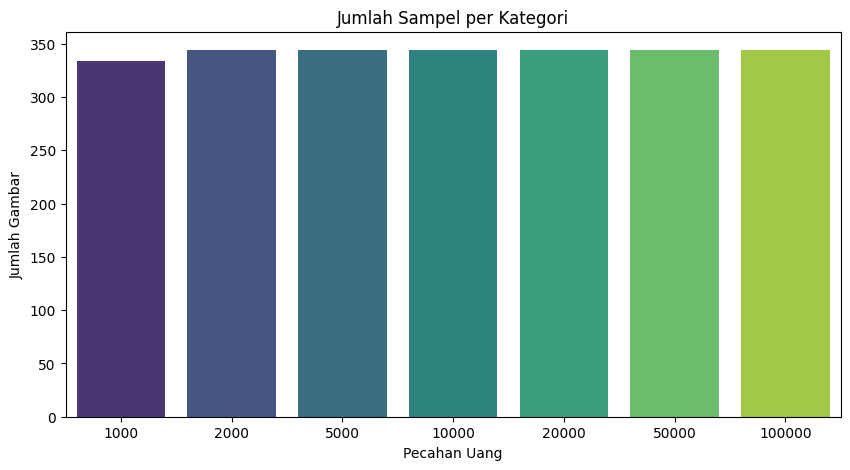

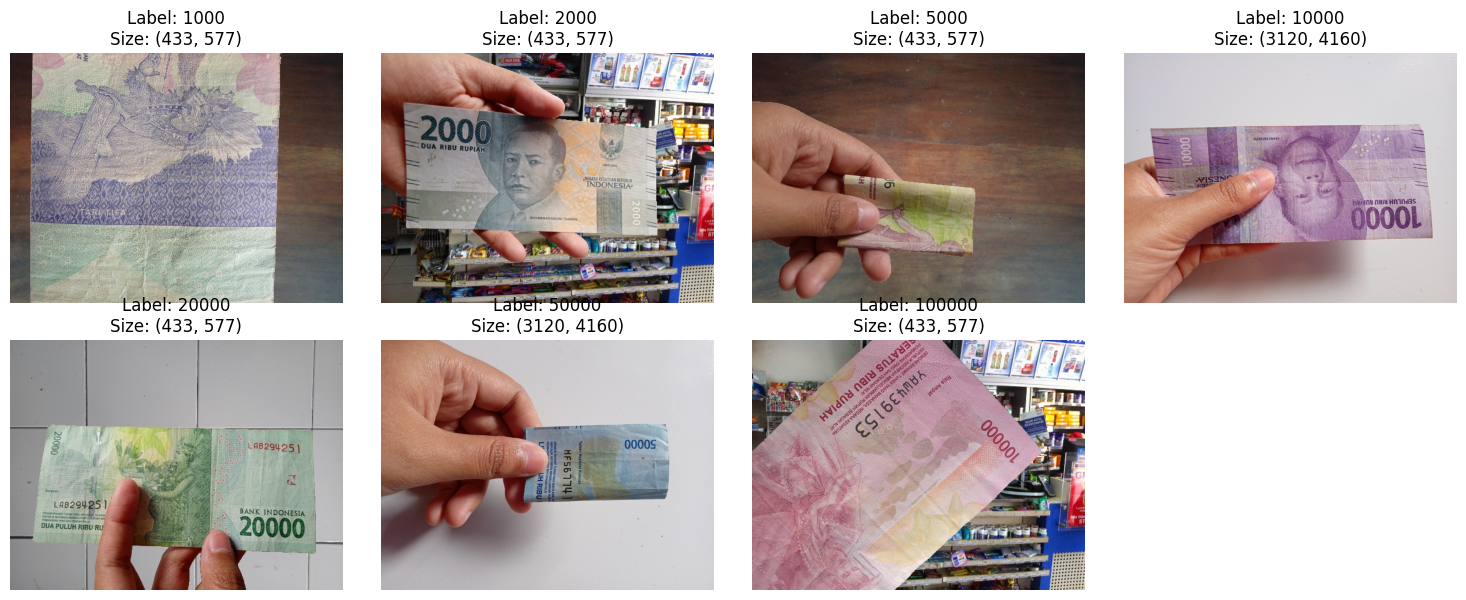

In [2]:
import random

def perform_eda(data_path, categories):
    print("--- Memulai Exploratory Data Analysis (EDA) ---")
    
    # 1. Menghitung Jumlah Data (Class Distribution)
    count_dict = {cat: len(list((data_path / cat).glob('*'))) for cat in categories}
    print(f"Distribusi Kelas: {count_dict}")
    
    # Visualisasi Distribusi
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=list(count_dict.keys()), 
        y=list(count_dict.values()), 
        hue=list(count_dict.keys()), 
        palette='viridis', 
        legend=False
    )
    plt.title('Jumlah Sampel per Kategori')
    plt.xlabel('Pecahan Uang')
    plt.ylabel('Jumlah Gambar')
    plt.show()
    
    # 2. Visualisasi Contoh Gambar
    plt.figure(figsize=(15, 6))
    
    for i, category in enumerate(categories):
        folder = data_path / category
        sample_images = random.sample(list(folder.glob('*')), 1) 
        
        for j, img_path in enumerate(sample_images):
            plt.subplot(2, 4, i + 1) 
            
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.imshow(img_rgb)
            plt.title(f"Label: {category}\nSize: {img.shape[:2]}")
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

# Panggil fungsi EDA
perform_eda(DATA_PATH, CATEGORIES)

In [3]:
# --- Inisialisasi MobileNetV2 sebagai Feature Extractor ---

# include_top=False → buang fully-connected head (classifier asli ImageNet)
# pooling='avg'    → tambahkan GlobalAveragePooling2D otomatis → output (None, 1280)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    pooling='avg',
    weights='imagenet'
)

# Freeze semua layer → kita hanya pakai MobileNet untuk ekstraksi, bukan training
base_model.trainable = False

MOBILENET_DIM = 1280   # Dimensi fitur output MobileNetV2 + GlobalAveragePooling
IMG_SIZE = (224, 224)  # Ukuran input standar MobileNetV2

print(f"MobileNetV2 berhasil dimuat.")
print(f"Dimensi fitur output: {MOBILENET_DIM} (menggantikan 32 dimensi ORB)")

I0000 00:00:1779293182.985300      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779293182.991697      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 berhasil dimuat.
Dimensi fitur output: 1280 (menggantikan 32 dimensi ORB)


In [4]:
def extract_mobilenet_features(img_path):
    """
    Membaca gambar, melakukan preprocessing sesuai standar MobileNetV2,
    lalu mengekstrak vektor fitur berdimensi 1280 menggunakan
    MobileNetV2 pretrained ImageNet (tanpa layer classifier).
    Mengembalikan array 1D berisi nilai fitur float32.
    """
    # 1. Baca gambar
    img = cv2.imread(str(img_path))
    if img is None:
        return None

    # 2. Konversi BGR → RGB (MobileNet dilatih dengan gambar RGB)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3. Resize ke ukuran input standar MobileNetV2: 224×224
    img_resized = cv2.resize(img_rgb, IMG_SIZE)

    # 4. Tambahkan dimensi batch: (224, 224, 3) → (1, 224, 224, 3)
    img_array = np.expand_dims(img_resized.astype('float32'), axis=0)

    # 5. Preprocessing khusus MobileNetV2: normalisasi ke rentang [-1, 1]
    img_preprocessed = preprocess_input(img_array)

    # 6. Forward pass melalui MobileNetV2 → vektor fitur (1, 1280)
    features = base_model.predict(img_preprocessed, verbose=0)

    # 7. Flatten → array 1D (1280,)
    return features.flatten().astype('float32')

I0000 00:00:1779293186.716593     135 service.cc:152] XLA service 0x7be9c4002f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779293186.716628     135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779293186.716631     135 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779293187.324960     135 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-20 16:06:35.398337: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 16:06:35.538152: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 16:06:35.670458: E external/local_xl

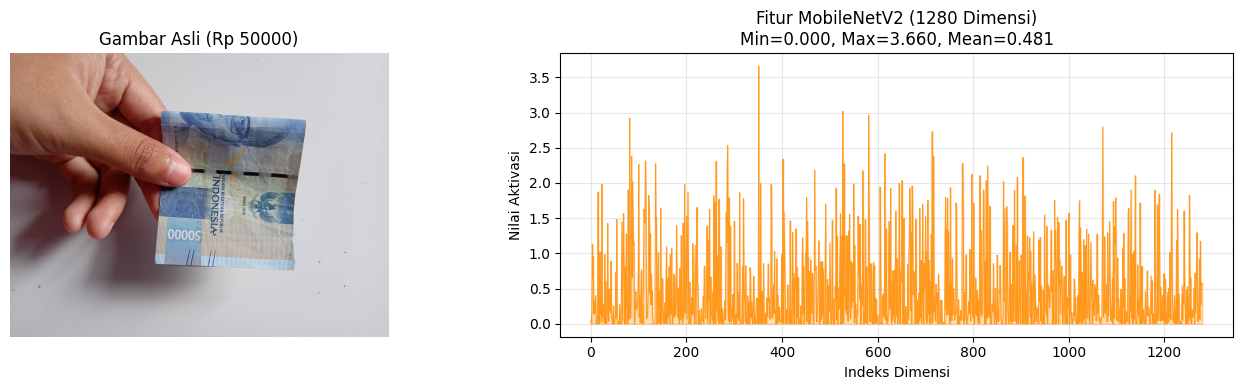

Bentuk vektor fitur MobileNetV2: (1280,)


In [5]:
# Ambil satu gambar acak dari dataset (misal dari folder 50000)
sample_cat = '50000'
sample_folder = DATA_PATH / sample_cat
sample_path = random.choice(list(sample_folder.glob('*')))

# Lakukan ekstraksi ciri MobileNetV2 pada gambar sampel
mobilenet_features = extract_mobilenet_features(sample_path)

# Baca gambar asli untuk ditampilkan
img_bgr = cv2.imread(str(sample_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Visualisasi
plt.figure(figsize=(14, 4))

# Plot 1: Gambar Asli
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title(f"Gambar Asli (Rp {sample_cat})")
plt.axis('off')

# Plot 2: Histogram distribusi 1280 nilai fitur MobileNet
plt.subplot(1, 2, 2)
plt.plot(mobilenet_features, color='darkorange', alpha=0.8, linewidth=0.7)
plt.fill_between(range(len(mobilenet_features)), mobilenet_features,
                 alpha=0.3, color='darkorange')
plt.title(f"Fitur MobileNetV2 (1280 Dimensi)\nMin={mobilenet_features.min():.3f}, "
          f"Max={mobilenet_features.max():.3f}, Mean={mobilenet_features.mean():.3f}")
plt.xlabel("Indeks Dimensi")
plt.ylabel("Nilai Aktivasi")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Bentuk vektor fitur MobileNetV2: {mobilenet_features.shape}")

In [6]:
X_list = []
y_list = []

# 1. Kumpulkan semua path gambar dan index labelnya
image_data = []
for i, category in enumerate(CATEGORIES):
    folder = DATA_PATH / category
    for img_path in folder.glob('*'):
        image_data.append((img_path, i))

print(f"Total gambar yang akan diproses: {len(image_data)}")

# 2. Fungsi pembantu untuk memproses satu data
def process_single_image(data):
    path, label_idx = data
    features = extract_mobilenet_features(path)
    return features, label_idx

# 3. Eksekusi Paralel
# Menggunakan ThreadPoolExecutor (bukan ProcessPoolExecutor) karena
# model Keras/TensorFlow tidak dapat di-pickle antar proses.
with ThreadPoolExecutor() as executor:
    futures = {executor.submit(process_single_image, data): data for data in image_data}

    for future in tqdm(as_completed(futures), total=len(image_data), desc="Ekstraksi Ciri MobileNetV2"):
        features, label_idx = future.result()
        if features is not None:
            X_list.append(features)
            y_list.append(label_idx)

Total gambar yang akan diproses: 2398


Ekstraksi Ciri MobileNetV2: 100%|██████████| 2398/2398 [02:14<00:00, 17.82it/s]


In [7]:
# 1. Konversi List ke Numpy Array
X = np.array(X_list).astype('float32')
y = np.array(y_list)

print("--- Preprocessing Label & Split Data ---")

# 2. One-Hot Encoding Label
num_classes = len(CATEGORIES)
y_one_hot = np.eye(num_classes)[y]

# 3. Train-Test Split (80% Data Latih, 20% Data Uji)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_one_hot, test_size=0.2, random_state=42, stratify=y
)

print(f"Bentuk Input (X_train) : {X_train.shape} -> Siap masuk Input Layer JST ({MOBILENET_DIM} Neuron)")
print(f"Bentuk Target (y_train): {y_train.shape} -> Siap masuk Output Layer JST ({num_classes} Neuron)")
print(f"Jumlah Data Uji (Test) : {len(X_test)} gambar")

--- Preprocessing Label & Split Data ---
Bentuk Input (X_train) : (1918, 1280) -> Siap masuk Input Layer JST (1280 Neuron)
Bentuk Target (y_train): (1918, 7) -> Siap masuk Output Layer JST (7 Neuron)
Jumlah Data Uji (Test) : 480 gambar


In [8]:
class ManualBackprop:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.lr = learning_rate
        
        # Inisialisasi He untuk kestabilan awal
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
        self.b2 = np.zeros((1, output_size))
        
        self.loss_history = []
        self.acc_history = []

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, A):
        return (A > 0).astype(float)

    # Fungsi Softmax untuk mengubah output jadi persentase peluang
    def softmax(self, x):
        exps = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exps / np.sum(exps, axis=1, keepdims=True)

    def train(self, X, y, epochs):
        m = X.shape[0]  # Jumlah total data gambar

        for epoch in range(epochs):
            # A. FEED FORWARD
            Z1 = np.dot(X, self.W1) + self.b1
            A1 = self.relu(Z1)
            
            Z2 = np.dot(A1, self.W2) + self.b2
            A2 = self.softmax(Z2)
            
            # B. HITUNG ERROR (CROSS ENTROPY)
            epsilon = 1e-15  # Mencegah error log(0)
            loss = -np.sum(y * np.log(A2 + epsilon)) / m
            self.loss_history.append(loss)
            
            # Hitung akurasi
            predictions = np.argmax(A2, axis=1)
            true_labels = np.argmax(y, axis=1)
            accuracy = np.mean(predictions == true_labels)
            self.acc_history.append(accuracy)
            
            # C. BACKPROPAGATION
            dZ2 = A2 - y 
            dW2 = np.dot(A1.T, dZ2) / m
            db2 = np.sum(dZ2, axis=0, keepdims=True) / m
            
            dA1 = np.dot(dZ2, self.W2.T)
            dZ1 = dA1 * self.relu_derivative(A1)
            dW1 = np.dot(X.T, dZ1) / m
            db1 = np.sum(dZ1, axis=0, keepdims=True) / m
            
            # D. UPDATE BOBOT
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            
            if (epoch + 1) % 500 == 0:
                print(f"Epoch {epoch+1:4d}/{epochs} | Loss: {loss:.4f} | Accuracy: {accuracy*100:.2f}%")

    def predict(self, X):
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = self.relu(Z1)
        Z2 = np.dot(A1, self.W2) + self.b2
        return self.softmax(Z2)

Epoch  500/3000 | Loss: 1.3318 | Accuracy: 59.85%
Epoch 1000/3000 | Loss: 0.9935 | Accuracy: 76.90%
Epoch 1500/3000 | Loss: 0.8003 | Accuracy: 83.94%
Epoch 2000/3000 | Loss: 0.6748 | Accuracy: 88.01%
Epoch 2500/3000 | Loss: 0.5860 | Accuracy: 90.67%
Epoch 3000/3000 | Loss: 0.5194 | Accuracy: 92.18%


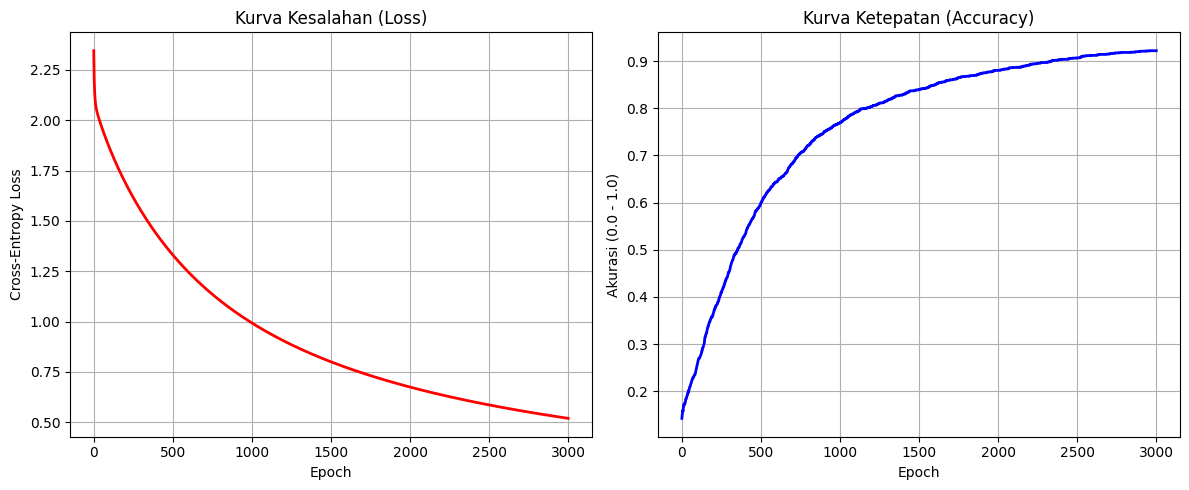

In [10]:
# INPUT_NEURON sekarang otomatis = 1280 (dimensi MobileNetV2)
INPUT_NEURON  = X_train.shape[1]    # 1280
HIDDEN_NEURON = 3560
OUTPUT_NEURON = y_train.shape[1]    # 7 (jumlah kelas pecahan)

EPOCHS        = 3000
LEARNING_RATE = 0.0005

model = ManualBackprop(INPUT_NEURON, HIDDEN_NEURON, OUTPUT_NEURON, LEARNING_RATE)
model.train(X_train, y_train, epochs=EPOCHS)

# Visualisasi Kurva Pembelajaran (Loss & Accuracy)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model.loss_history, color='red', linewidth=2)
plt.title('Kurva Kesalahan (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(model.acc_history, color='blue', linewidth=2)
plt.title('Kurva Ketepatan (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Akurasi (0.0 - 1.0)')
plt.grid(True)

plt.tight_layout()
plt.show()

Akurasi pada Data Uji (Unseen Data): 79.79%



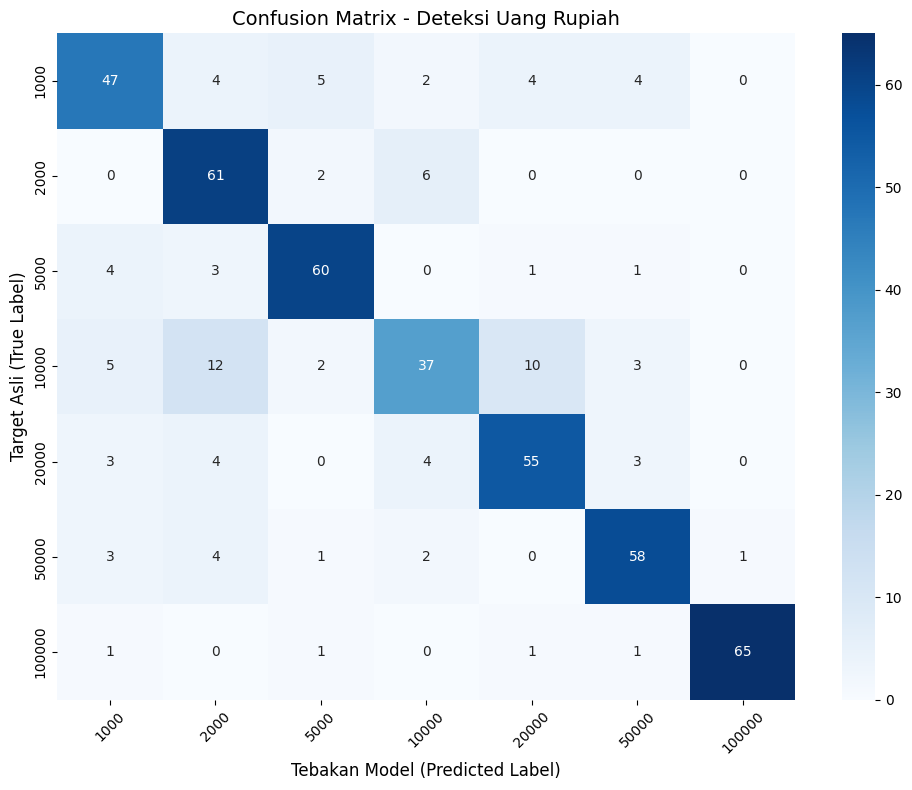


--- Laporan Klasifikasi Lengkap ---
              precision    recall  f1-score   support

        1000       0.75      0.71      0.73        66
        2000       0.69      0.88      0.78        69
        5000       0.85      0.87      0.86        69
       10000       0.73      0.54      0.62        69
       20000       0.77      0.80      0.79        69
       50000       0.83      0.84      0.83        69
      100000       0.98      0.94      0.96        69

    accuracy                           0.80       480
   macro avg       0.80      0.80      0.79       480
weighted avg       0.80      0.80      0.80       480



In [11]:
# 1. Prediksi seluruh data uji (X_test)
y_pred_probs   = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Hitung Akurasi Testing
test_accuracy = np.mean(y_pred_classes == y_true_classes)
print(f"Akurasi pada Data Uji (Unseen Data): {test_accuracy * 100:.2f}%\n")

# 3. Visualisasi Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title('Confusion Matrix - Deteksi Uang Rupiah', fontsize=14)
plt.ylabel('Target Asli (True Label)', fontsize=12)
plt.xlabel('Tebakan Model (Predicted Label)', fontsize=12)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

# 4. Laporan Performa (Precision, Recall, F1-Score)
print("\n--- Laporan Klasifikasi Lengkap ---")
print(classification_report(y_true_classes, y_pred_classes,
                             target_names=CATEGORIES, zero_division=0))

Mengambil 3 gambar acak dari dataset untuk dites secara visual...

Target Asli: Rp 100000


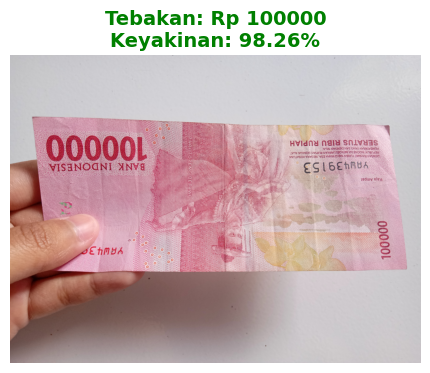

--------------------------------------------------
Target Asli: Rp 100000


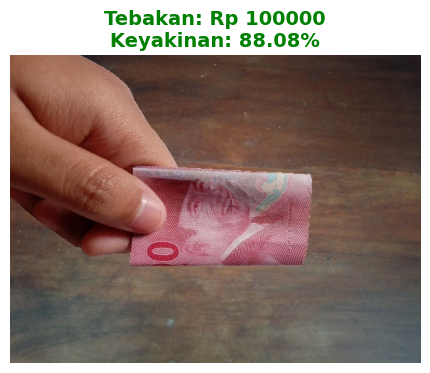

--------------------------------------------------
Target Asli: Rp 10000


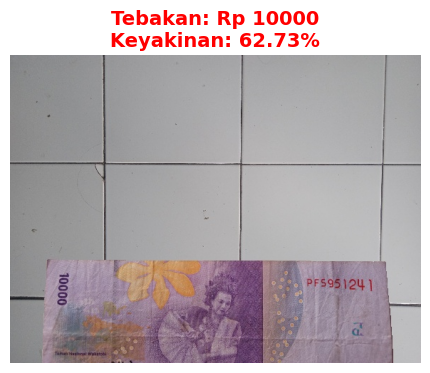

--------------------------------------------------


In [12]:
def predict_and_visualize(img_path):
    # 1. Ekstraksi ciri gambar menggunakan MobileNetV2
    features = extract_mobilenet_features(img_path)

    if features is None:
        print("Gambar tidak dapat dibaca!")
        return

    # 2. Menyesuaikan bentuk array (1 baris, 1280 kolom)
    features_input = features.reshape(1, -1)

    # 3. Lakukan Prediksi
    probs = model.predict(features_input)[0]
    predicted_idx   = np.argmax(probs)
    predicted_label = CATEGORIES[predicted_idx]
    confidence      = probs[predicted_idx] * 100

    # 4. Baca gambar asli untuk ditampilkan
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 5. Visualisasi Hasil
    plt.figure(figsize=(6, 4))
    plt.imshow(img_rgb)

    color = 'green' if confidence >= 80 else 'red'

    plt.title(f"Tebakan: Rp {predicted_label}\nKeyakinan: {confidence:.2f}%",
              fontsize=14, color=color, fontweight='bold')
    plt.axis('off')
    plt.show()


print("Mengambil 3 gambar acak dari dataset untuk dites secara visual...\n")

for _ in range(3):
    random_category   = random.choice(CATEGORIES)
    folder            = DATA_PATH / random_category
    random_image_path = random.choice(list(folder.glob('*')))

    print(f"Target Asli: Rp {random_category}")
    predict_and_visualize(random_image_path)
    print("-" * 50)

In [13]:
# ============================================================
# EXPORT FULL MODEL KE FORMAT .h5
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# ============================================================
# BANGUN ULANG MODEL KERAS
# ============================================================

keras_model = Sequential([
    Input(shape=(INPUT_NEURON,)),

    Dense(
        HIDDEN_NEURON,
        activation='relu',
        name='hidden_layer'
    ),

    Dense(
        OUTPUT_NEURON,
        activation='softmax',
        name='output_layer'
    )
])

# ============================================================
# TRANSFER BOBOT DARI ManualBackprop
# ============================================================

keras_model.layers[0].set_weights([
    model.W1,
    model.b1.flatten()
])

keras_model.layers[1].set_weights([
    model.W2,
    model.b2.flatten()
])

# ============================================================
# SIMPAN FULL MODEL KE .h5
# ============================================================

MODEL_PATH = "rupiah_classifier_mobilenet_full.h5"

keras_model.save(MODEL_PATH)

print(f"✅ Full model berhasil disimpan:")
print(MODEL_PATH)

# ============================================================
# VERIFIKASI MODEL
# ============================================================

loaded_model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

sample_pred = loaded_model.predict(
    X_test[:5],
    verbose=0
)

print("\n✅ Model berhasil di-load ulang")
print("Prediksi sample:", sample_pred.argmax(axis=1))

✅ Full model berhasil disimpan:
rupiah_classifier_mobilenet_full.h5

✅ Model berhasil di-load ulang
Prediksi sample: [2 4 0 4 4]
